# Trump on Reddit: exploratory data analysis

**Homework #3.** The dataset is every Reddit submission and comment that mentions "Trump" in six political subreddits, collected in Homework #2 and cleaned in `notebooks/preprocessing/reddit_cleaning.ipynb`.

**Project idea.** We follow how support for Trump and opposition to him change in Reddit comments over time, and compare his first term (2017–2018) with his second (2025–2026).

**Time spent:** __ hours

## 1. Basic data exploration

This section describes the dataset before any stance analysis: what it contains, how complete it is, and how records spread over time, communities, authors and threads.

Every comparison uses the same four windows, so the two terms are compared at the same point of the presidency:

| Window | Months | Meaning |
|---|---|---|
| `T1_Y1` | Jan–Jun 2017 | first term, first year |
| `T1_Y2` | Jan–Jun 2018 | first term, second year |
| `T2_Y1` | Jan–Jun 2025 | second term, first year |
| `T2_Y2` | Jan–Jun 2026 | second term, second year |

Two limits apply to everything below:

- The data is already filtered to records that mention Trump. The charts show volume and composition inside this dataset, not Trump's share of all Reddit discussion.
- r/politics holds about 90% of the comments, so the charts also show each subreddit separately.

### 1.1 Setup and loading

In [1]:
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.parquet as pq
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, PercentFormatter

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 130)

ROOT = Path.cwd()

while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if not (ROOT / "data").exists():
    raise FileNotFoundError("Could not find project root with data/ directory.")

CLEAN = ROOT / "data" / "cleaned"
SUBMISSIONS_PATH = CLEAN / "submissions_clean.parquet"
COMMENTS_PATH = CLEAN / "comments_clean.parquet"

In [2]:
PERIODS = ["T1_Y1", "T1_Y2", "T2_Y1", "T2_Y2"]
PERIOD_YEAR = {"T1_Y1": 2017, "T1_Y2": 2018, "T2_Y1": 2025, "T2_Y2": 2026}
PERIOD_SHORT = {p: f"{y}\n{p[:2]}, year {p[-1]}" for p, y in PERIOD_YEAR.items()}
PERIOD_LONG = {p: f"Jan–Jun {y} ({'first' if p[:2] == 'T1' else 'second'} term, year {p[-1]})" for p, y in PERIOD_YEAR.items()}
PERIOD_LINESTYLE = {"T1_Y1": "-", "T1_Y2": "--", "T2_Y1": "-", "T2_Y2": "--"}
TERMS = ["T1", "T2"]
TERM_LABEL = {"T1": "First term (2017–2018)", "T2": "Second term (2025–2026)"}
MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
WEEKDAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
ET = "America/New_York"

# subreddits ordered by number of comments
SUBREDDITS = ["politics", "AskTrumpSupporters", "Conservative", "PoliticalDiscussion", "democrats", "Republican"]
STANCES = ["supporter", "undecided", "nonsupporter"]

# colours: one meaning per colour in the whole notebook
TERM_COLOR = {"T1": "#2a78d6", "T2": "#eb6834"}
PERIOD_COLOR = {p: TERM_COLOR[p[:2]] for p in PERIODS}
SUB_COLOR = dict(zip(SUBREDDITS, ["#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]))
STANCE_COLOR = {"supporter": "#e34948", "undecided": "#b9b8b1", "nonsupporter": "#2a78d6"}
NEUTRAL = "#6b6a66"
INK, INK_2, MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUES = mcolors.LinearSegmentedColormap.from_list("blues", ["#eef5fe", "#b7d3f6", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 10, "text.color": INK,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.titlesize": 10, "axes.titleweight": "normal", "axes.titlelocation": "left", "axes.titlecolor": INK_2,
    "axes.labelsize": 9.5, "axes.labelcolor": INK_2,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 2,
})


def compact(x, _=None):
    """Tick label: 1500 -> 1.5K, 2000000 -> 2M."""
    if abs(x) >= 1e6:
        return f"{x / 1e6:g}M"
    if abs(x) >= 1e3:
        return f"{x / 1e3:g}K"
    return f"{x:g}"


COMPACT = FuncFormatter(compact)
PERCENT = FuncFormatter(lambda x, _: f"{x:g}%")


def headline(fig, text):
    fig.suptitle(text, x=0.01, ha="left", fontsize=12.5, fontweight="bold", color=INK)


def term_handles(marker=None):
    if marker:
        return [Line2D([], [], color=TERM_COLOR[t], marker=marker, linestyle="", markersize=8, label=TERM_LABEL[t]) for t in TERMS]
    return [Patch(color=TERM_COLOR[t], label=TERM_LABEL[t]) for t in TERMS]


def ink_on(fill):
    """Black or white text, whichever reads better on the given fill colour."""
    r, g, b = mcolors.to_rgb(fill)
    return INK if 0.2126 * r + 0.7152 * g + 0.0722 * b > 0.55 else "white"


def with_commas(df):
    """Integer columns as strings with thousands separators (for display only)."""
    return df.apply(lambda s: s.map("{:,}".format) if pd.api.types.is_integer_dtype(s) else s)

The comments are loaded without the two text columns (`body`, `body_clean`), which would need about 7 GB of RAM.

In [3]:
subs = pd.read_parquet(SUBMISSIONS_PATH)

comments_file = pq.ParquetFile(COMMENTS_PATH)
TEXT_COLUMNS = ["body", "body_clean"]
light_columns = [c for c in comments_file.schema_arrow.names if c not in TEXT_COLUMNS]
com = pd.read_parquet(COMMENTS_PATH, columns=light_columns)

n_words, n_chars = [], []
for i in range(comments_file.metadata.num_row_groups):
    body = comments_file.read_row_group(i, columns=["body_clean"])["body_clean"]
    n_words.append(pc.count_substring_regex(body, r"\S+").to_numpy())
    n_chars.append(pc.utf8_length(body).to_numpy())

assert sum(len(a) for a in n_words) == len(com)
com["n_words"] = np.concatenate(n_words).astype("int32")
com["n_chars"] = np.concatenate(n_chars).astype("int32")
del n_words, n_chars, body

# US Eastern time for everything about days and hours: the audience and the events are mostly American
for df in (subs, com):
    local = df["created_at"].dt.tz_convert(ET).dt.tz_localize(None)
    df["date_et"] = local.dt.normalize()
    df["hour_et"] = local.dt.hour.astype("int8")
    df["weekday_et"] = local.dt.dayofweek.astype("int8")
del local

print(f"submissions: {subs.shape[0]:,} rows x {subs.shape[1]} columns, {subs.memory_usage(deep=True).sum() / 1024**3:.2f} GB in memory")
print(f"comments:    {com.shape[0]:,} rows x {com.shape[1]} columns, {com.memory_usage(deep=True).sum() / 1024**3:.2f} GB in memory")

submissions: 497,211 rows x 35 columns, 0.30 GB in memory
comments:    4,514,780 rows x 25 columns, 0.79 GB in memory


### 1.2 What is in the dataset

**Question:** how many records do we have, from when, and what does one record look like?

In [4]:
def overview(df, path, thread_column):
    meta = pq.ParquetFile(path).metadata
    return {
        "rows": f"{meta.num_rows:,}",
        "columns in the file": meta.num_columns,
        "file size": f"{path.stat().st_size / 1024**2:,.0f} MB",
        "first record (UTC)": f"{df['created_at'].min():%Y-%m-%d %H:%M}",
        "last record (UTC)": f"{df['created_at'].max():%Y-%m-%d %H:%M}",
        "subreddits": df["subreddit"].nunique(),
        "unique authors (without [deleted])": f"{df.loc[~df['author_deleted'], 'author'].nunique():,}",
        "unique threads": f"{df[thread_column].nunique():,}",
    }


pd.DataFrame({
    "submissions": overview(subs, SUBMISSIONS_PATH, "id"),
    "comments": overview(com, COMMENTS_PATH, "submission_id"),
})

,submissions,comments
rows,"497,211","4,514,780"
columns in the file,32,22
file size,125 MB,"2,045 MB"
first record (UTC),2017-01-01 00:03,2017-01-01 00:00
last record (UTC),2026-06-30 23:59,2026-06-30 23:58
subreddits,6,6
unique authors (without [deleted]),"76,890","482,468"
unique threads,"497,211","325,714"


In [5]:
named = com.loc[~com["author_deleted"]]          # comments whose author is known

by_period = pd.DataFrame({
    "submissions": subs.groupby("period").size(),
    "comments": com.groupby("period").size(),
    "comment authors": named.groupby("period")["author"].nunique(),
    "threads with comments": com.groupby("period")["submission_id"].nunique(),
})
by_period["comments per author"] = (by_period["comments"] / by_period["comment authors"]).round(1)
by_period["comments per thread"] = (by_period["comments"] / by_period["threads with comments"]).round(1)
by_period.index = [PERIOD_LONG[p] for p in by_period.index]
with_commas(by_period)

,submissions,comments,comment authors,threads with comments,comments per author,comments per thread
"Jan–Jun 2017 (first term, year 1)","192,036","1,723,090","166,876","118,704",10.3,14.5
"Jan–Jun 2018 (first term, year 2)","150,335","1,366,732","144,335","101,016",9.5,13.5
"Jan–Jun 2025 (second term, year 1)","94,650","854,162","180,079","61,230",4.7,14.0
"Jan–Jun 2026 (second term, year 2)","60,190","570,796","120,876","44,858",4.7,12.7


The columns fall into six groups, the same in both tables.

| Group | Submissions | Comments |
|---|---|---|
| Identity and links | `id` | `id`, `submission_id` (the thread), `parent_id` (what it replies to), `is_top_level` |
| When and where | `created_utc`, `created_at`, `source_month`, `year`, `period`, `term`, `subreddit` | the same |
| Who | `author`, `author_deleted`, `author_flair_text`, `stance` | the same |
| What | `title`, `selftext`, `text`, `text_clean`, `is_self`, `domain`, `url`, `link_flair_text` | `body`, `body_clean` |
| Reception | `score`, `num_comments`, `upvote_ratio` | `score`, `controversiality` |
| Cleaning flags | `selftext_deleted`, `selftext_removed`, `title_unusable`, `is_mod_or_bot_post`, `submission_mentions_trump`, `has_trump_comment`, `in_scope`, `removed_by_category`, `stickied` | `trump_only_in_quote`, `edited`, `stickied` |

`stance` is the **declared stance** of the author (supporter, nonsupporter, undecided). It comes from the mandatory flair of r/AskTrumpSupporters and exists only there.

In [6]:
# one comment from each window (authors are left out on purpose)
sample_columns = ["created_at", "subreddit", "period", "stance", "score", "controversiality", "is_top_level", "body_clean"]
sample = pd.concat(
    [comments_file.read_row_group(i, columns=sample_columns).slice(500, 1).to_pandas() for i in (0, 9, 16, 22)],
    ignore_index=True,
)
sample["created_at"] = sample["created_at"].dt.strftime("%Y-%m-%d %H:%M")
sample["body_clean"] = sample["body_clean"].str.replace("\n", " ").str.slice(0, 120) + "…"
sample

,created_at,subreddit,period,stance,score,controversiality,is_top_level,body_clean
0,2017-01-01 01:35,PoliticalDiscussion,T1_Y1,<NA>,2,0,False,"True. However, I thought it was a pretty accurate characterization of stuff Trump says.…"
1,2018-01-07 02:30,politics,T1_Y2,<NA>,94,0,False,It’s been renamed the Trump-Fox effect.…
2,2025-01-15 02:51,politics,T2_Y1,<NA>,3,0,True,“I am nominating Eleon to lead the SEC.” -Trump tomorrow…
3,2026-04-18 11:45,politics,T2_Y2,<NA>,1,0,False,"""Trump will do bad things"" \*Loses the election, Trump does bad things\* ""Told you so!"" Wow, incredible stuff. She's nev…"


**What we see.**

- 497,211 submissions and 4,514,780 comments, about nine comments per submission, in four six-month windows between January 2017 and June 2026.
- Volume falls from window to window: 1.72M comments in 2017, 1.37M in 2018, 0.85M in 2025 and 0.57M in 2026.
- The number of authors does not fall with it. 2025 has the most authors (180,079) and half the comments of 2017: about 10 comments per author in the first term, under 5 in the second.

### 1.3 Data quality

**Question:** which columns have missing values, and is the loss of content (deleted or removed records) the same in every window?

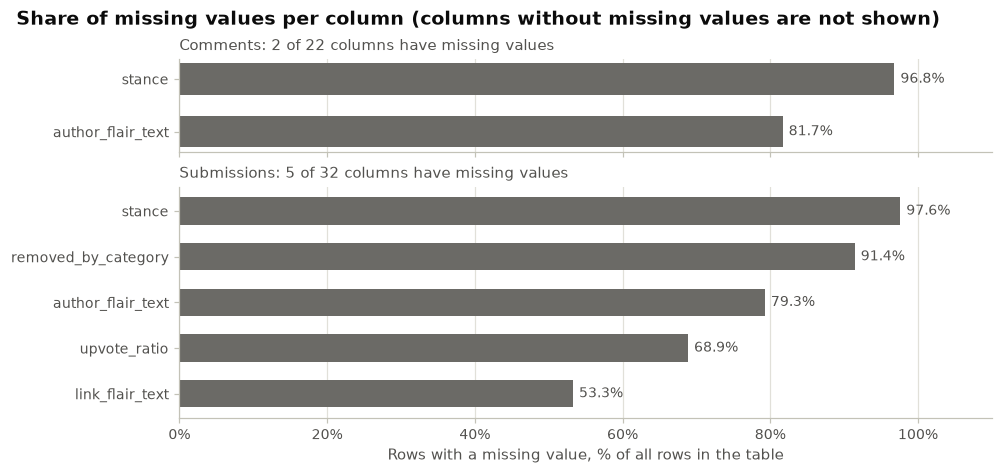

In [7]:
def null_share(path):
    """% of nulls per column, read from the parquet footer where possible (no data is loaded)."""
    f = pq.ParquetFile(path)
    meta = f.metadata
    out = {}
    for j in range(meta.num_columns):
        name = meta.schema.column(j).name
        stats = [meta.row_group(i).column(j).statistics for i in range(meta.num_row_groups)]
        if all(s is not None and s.has_null_count for s in stats):
            out[name] = sum(s.null_count for s in stats)
        else:
            out[name] = f.read(columns=[name])[name].null_count
    return 100 * pd.Series(out) / meta.num_rows


nulls = {"Comments": null_share(COMMENTS_PATH), "Submissions": null_share(SUBMISSIONS_PATH)}
with_nulls = {k: s[s > 0].sort_values() for k, s in nulls.items()}

fig, axes = plt.subplots(2, 1, figsize=(9, 4.2), sharex=True, layout="constrained",
                         gridspec_kw={"height_ratios": [len(s) for s in with_nulls.values()]})
for ax, (name, s) in zip(axes, with_nulls.items()):
    bars = ax.barh(s.index, s.values, height=0.6, color=NEUTRAL)
    ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9, color=INK_2)
    ax.set_title(f"{name}: {len(s)} of {len(nulls[name])} columns have missing values")
    ax.grid(axis="y", visible=False)
axes[-1].set_xlim(0, 110)
axes[-1].set_xticks(range(0, 101, 20))
axes[-1].xaxis.set_major_formatter(PERCENT)
axes[-1].set_xlabel("Rows with a missing value, % of all rows in the table")
headline(fig, "Share of missing values per column (columns without missing values are not shown)")
plt.show()

**What we see.** Missing values appear only in optional metadata, and each gap has a structural reason:

- `stance` exists only in r/AskTrumpSupporters, which is 3% of the data. `author_flair_text` and `link_flair_text` are optional flairs that most users and posts do not have.
- `upvote_ratio` and `removed_by_category` exist only in the 2025–2026 archive, so they are empty for the 68.9% of submissions that belong to the first term.
- The fields we rely on (ids, time, subreddit, author, text, score) are complete. Nothing needs to be imputed.

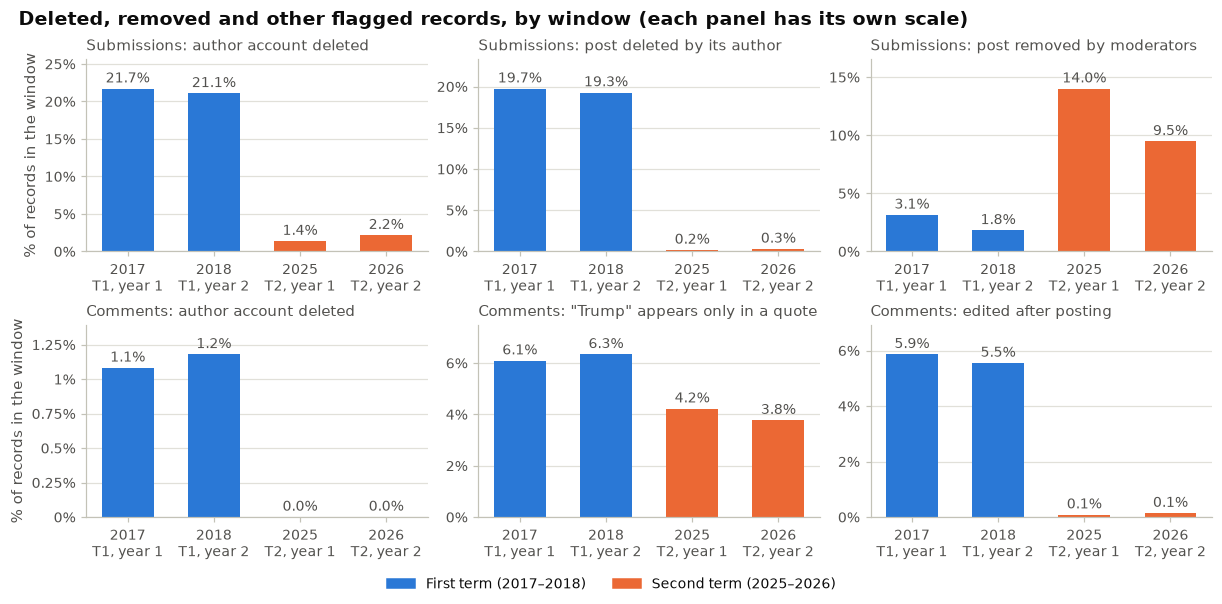

In [8]:
FLAGS = [
    (subs, "author_deleted", "Submissions: author account deleted"),
    (subs, "selftext_deleted", "Submissions: post deleted by its author"),
    (subs, "selftext_removed", "Submissions: post removed by moderators"),
    (com, "author_deleted", "Comments: author account deleted"),
    (com, "trump_only_in_quote", 'Comments: "Trump" appears only in a quote'),
    (com, "edited", "Comments: edited after posting"),
]

fig, axes = plt.subplots(2, 3, figsize=(11, 5.4), layout="constrained")
for ax, (df, column, label) in zip(axes.flat, FLAGS):
    share = 100 * df.groupby("period")[column].mean().astype(float).reindex(PERIODS)
    bars = ax.bar([PERIOD_SHORT[p] for p in PERIODS], share.values, width=0.6, color=[PERIOD_COLOR[p] for p in PERIODS])
    ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=9, color=INK_2)
    ax.set_title(label)
    ax.set_ylim(0, share.max() * 1.18)
    ax.yaxis.set_major_formatter(PERCENT)
    ax.grid(axis="x", visible=False)
for ax in axes[:, 0]:
    ax.set_ylabel("% of records in the window")
fig.legend(handles=term_handles(), loc="outside lower center", ncols=2)
headline(fig, "Deleted, removed and other flagged records, by window (each panel has its own scale)")
plt.show()

The flags differ sharply between the terms. The raw files record when the archive saved each record, so the cause can be measured.

In [9]:
RAW_DIR = next((d for d in (ROOT / "data", ROOT / "data" / "processed" / "combined") if (d / "comments_trump.parquet").exists()), None)

if RAW_DIR is None:
    print("Raw files from Homework #2 were not found, so the archive-lag check is skipped.")
else:
    lag = {}
    for name in ["comments", "submissions"]:
        raw = pd.read_parquet(RAW_DIR / f"{name}_trump.parquet", columns=["source_month", "created_utc", "retrieved_on", "_meta"])
        year = raw["source_month"].str[:4].rename("window")
        second_save = pd.to_numeric(raw["_meta"].str.extract(r"retrieved_2nd_on': (\d+)")[0])
        days = pd.DataFrame({
            "first save, days after posting": (raw["retrieved_on"] - raw["created_utc"]) / 86400,
            "second save, days after posting": (second_save - raw["created_utc"]) / 86400,
        })
        lag[name] = days.groupby(year).median()
        if name == "comments":
            edited_in_meta = 100 * raw["_meta"].str.contains("is_edited", na=False).groupby(year).mean()
    del raw, days, second_save
    display(pd.concat(lag, axis=1).round(1))
    print("median values; NaN = the archive made no second save")
    print("raw comments marked as edited inside `_meta`, %:", edited_in_meta.round(1).to_dict())

comments                                                    submissions                                
       first save, days after posting second save, days after posting first save, days after posting second save, days after posting
window                                                                                                                              
2017                             19.7                             NaN                           31.5                             NaN
2018                             26.3                             NaN                           33.5                             NaN
2025                              0.0                             1.5                            0.0                             1.5
2026                              0.0                             1.5                            0.0                             1.5

median values; NaN = the archive made no second save
raw comments marked as edited inside `_meta`, %: {'2017': 0.0, '2018': 0.0, '2025': 12.4, '2026': 10.7}


In [10]:
comment_counts = com.groupby("submission_id").size()

pd.Series({
    "duplicate submission ids": f"{subs['id'].duplicated().sum():,}",
    "duplicate comment ids": f"{com['id'].duplicated().sum():,}",
    "comments whose thread is in the submissions table": f"{100 * com['submission_id'].isin(subs['id']).mean():.2f}%",
    "submissions with at least one comment in the comments table": f"{100 * subs['id'].isin(comment_counts.index).mean():.2f}%",
    "submissions that mention Trump in the title or body": f"{100 * subs['submission_mentions_trump'].mean():.2f}%",
    "submissions posted by a moderator or bot": f"{100 * subs['is_mod_or_bot_post'].mean():.2f}%",
}, name="value").to_frame()

,value
duplicate submission ids,0
duplicate comment ids,0
comments whose thread is in the submissions table,99.80%
submissions with at least one comment in the comments table,65.12%
submissions that mention Trump in the title or body,69.00%
submissions posted by a moderator or bot,0.12%


**What we see.** The two terms were archived in different ways, and the flags show it.

- **Deletions.** In the first term about 21% of submissions come from deleted accounts and 19% were deleted by their authors. In the second term both are under 3%. The archive changed, not the people: first-term records were saved 3–5 weeks after posting, second-term records at the moment of posting and once more 1.5 days later. Later deletions are invisible in the second term.
- **Edits.** `edited` is not comparable: 5.5–5.9% in the first term and 0.1% in the second. The newer archive stores edits in `_meta` (11–12% of comments there), and the cleaning step did not carry them over.
- **Removals.** Moderator removals rise from 2–3% to 10–14% of submissions. This can be stricter moderation or better recording.
- **Quotes.** 6% of first-term and 4% of second-term comments mention Trump only inside a quote. They are left out of the stance analysis, because the words belong to someone else.

The integrity checks are clean: no duplicate ids, and 99.8% of comments have their thread in the submissions table.

**What it means for the project.** Deletions, edits and scores were recorded at different delays in the two terms, so differences between the terms in these fields can be artefacts.

### 1.4 Volume over time

**Question:** how many records are there per month, does the second term repeat the rhythm of the first, and which days stand out?

The four windows are not adjacent, so each gets its own block or panel and they are never joined with one line.

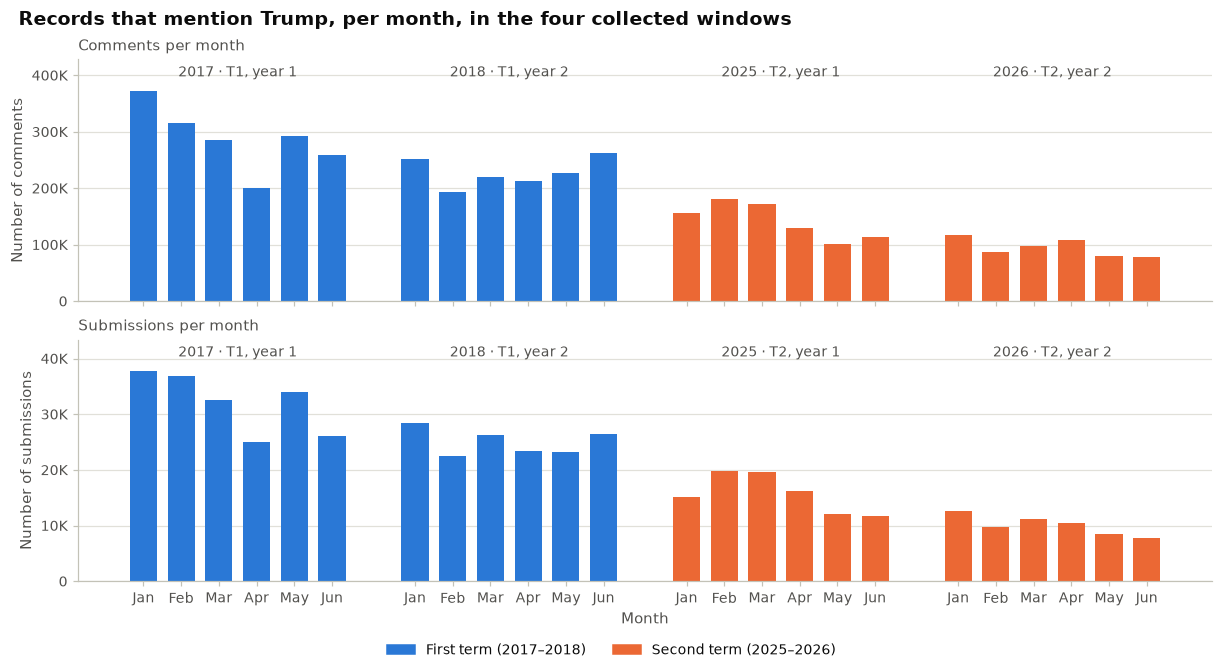

In [11]:
monthly = pd.DataFrame({
    "comments": com.groupby("source_month").size(),
    "submissions": subs.groupby("source_month").size(),
}).sort_index()
months = list(monthly.index)
x = np.array([i + (i // 6) * 1.2 for i in range(len(months))])       # a gap between windows
bar_colors = [TERM_COLOR["T1"] if m < "2020" else TERM_COLOR["T2"] for m in months]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, layout="constrained")
for ax, kind in zip(axes, ["comments", "submissions"]):
    ax.bar(x, monthly[kind].values, width=0.72, color=bar_colors)
    ax.set_title(f"{kind.capitalize()} per month")
    ax.set_ylabel(f"Number of {kind}")
    ax.yaxis.set_major_formatter(COMPACT)
    ax.grid(axis="x", visible=False)
    top = monthly[kind].max()
    ax.set_ylim(0, top * 1.15)
    for w, p in enumerate(PERIODS):
        ax.text(x[w * 6:(w + 1) * 6].mean(), top * 1.07, PERIOD_SHORT[p].replace("\n", " · "), ha="center", fontsize=9, color=INK_2)
axes[-1].set_xticks(x, MONTH_NAMES * 4)
axes[-1].set_xlabel("Month")
fig.legend(handles=term_handles(), loc="outside lower center", ncols=2)
headline(fig, "Records that mention Trump, per month, in the four collected windows")
plt.show()

**What we see.**

- Every month of the second term has fewer records than any month of the first. Comments go from 372K in January 2017 to 79K in June 2026, submissions from 38K to 8K.
- The fall is steady and continues inside the second term.

**Caution.** A lower count can mean less talk about Trump, less activity on these subreddits, more removed content or a less complete archive. The counts cannot separate these, so later sections compare shares.

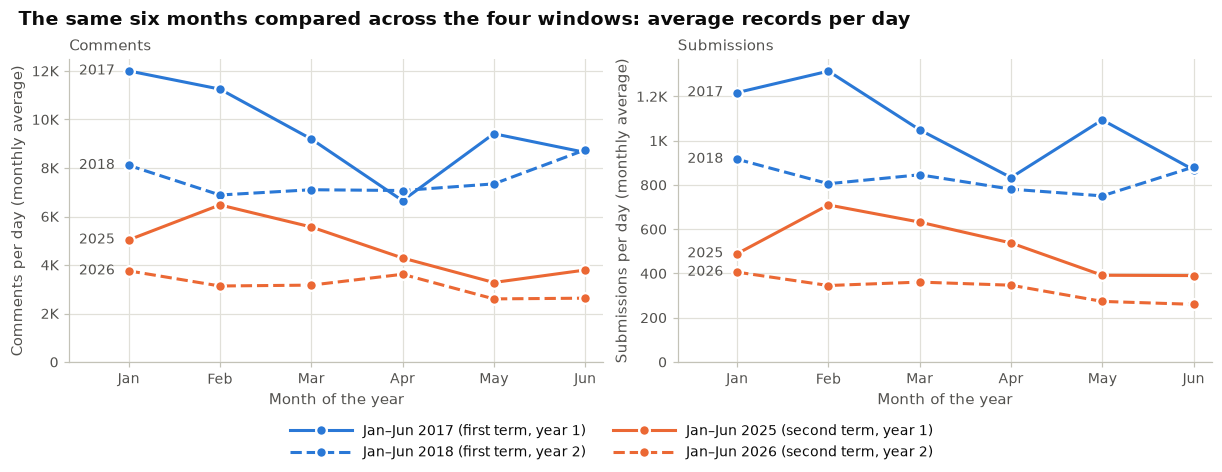

month,Jan,Feb,Mar,Apr,May,Jun
window,,,,,,
2017 comments per day,"12,004","11,252","9,196","6,655","9,414","8,644"
2018 comments per day,"8,110","6,886","7,104","7,072","7,345","8,748"
2025 comments per day,"5,035","6,477","5,568","4,289","3,279","3,793"
2026 comments per day,"3,759","3,135","3,171","3,618","2,603","2,632"


In [12]:
per_day = monthly.div(pd.PeriodIndex(months, freq="M").days_in_month.to_numpy(), axis=0)   # removes the short-February effect

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained")
for ax, kind in zip(axes, ["comments", "submissions"]):
    for p in PERIODS:
        y = per_day.loc[[m for m in months if m.startswith(str(PERIOD_YEAR[p]))], kind].to_numpy()
        ax.plot(range(6), y, color=PERIOD_COLOR[p], linestyle=PERIOD_LINESTYLE[p], marker="o", markersize=7,
                markeredgecolor="white", markeredgewidth=1.5, label=PERIOD_LONG[p])
        ax.annotate(str(PERIOD_YEAR[p]), (0, y[0]), xytext=(-9, 0), textcoords="offset points", ha="right", va="center", fontsize=9, color=INK_2)
    ax.set_xticks(range(6), MONTH_NAMES)
    ax.set_xlim(-0.65, 5.2)
    ax.set_ylim(0, None)
    ax.yaxis.set_major_formatter(COMPACT)
    ax.set_xlabel("Month of the year")
    ax.set_ylabel(f"{kind.capitalize()} per day (monthly average)")
    ax.set_title(kind.capitalize())
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=2, handlelength=4.5)
headline(fig, "The same six months compared across the four windows: average records per day")
plt.show()

comments_per_day = per_day["comments"].round(0).astype(int).to_frame()
comments_per_day["window"] = [f"{m[:4]} comments per day" for m in months]
comments_per_day["month"] = MONTH_NAMES * 4
with_commas(comments_per_day.pivot(index="window", columns="month", values="comments")[MONTH_NAMES])

**What we see.**

- Year 1 of each term starts high and decays: from 12.0K comments per day in January 2017 to 6.7K in April, and from 6.5K in February 2025 to 3.3K in May.
- Year 2 is flat: 6.9K–8.7K per day in 2018 and 2.6K–3.8K in 2026. So year 1 against year 1 and year 2 against year 2 are the fair comparisons.
- 2017 has a second wave in May (9.4K per day), which the daily chart below ties to the Comey memo.

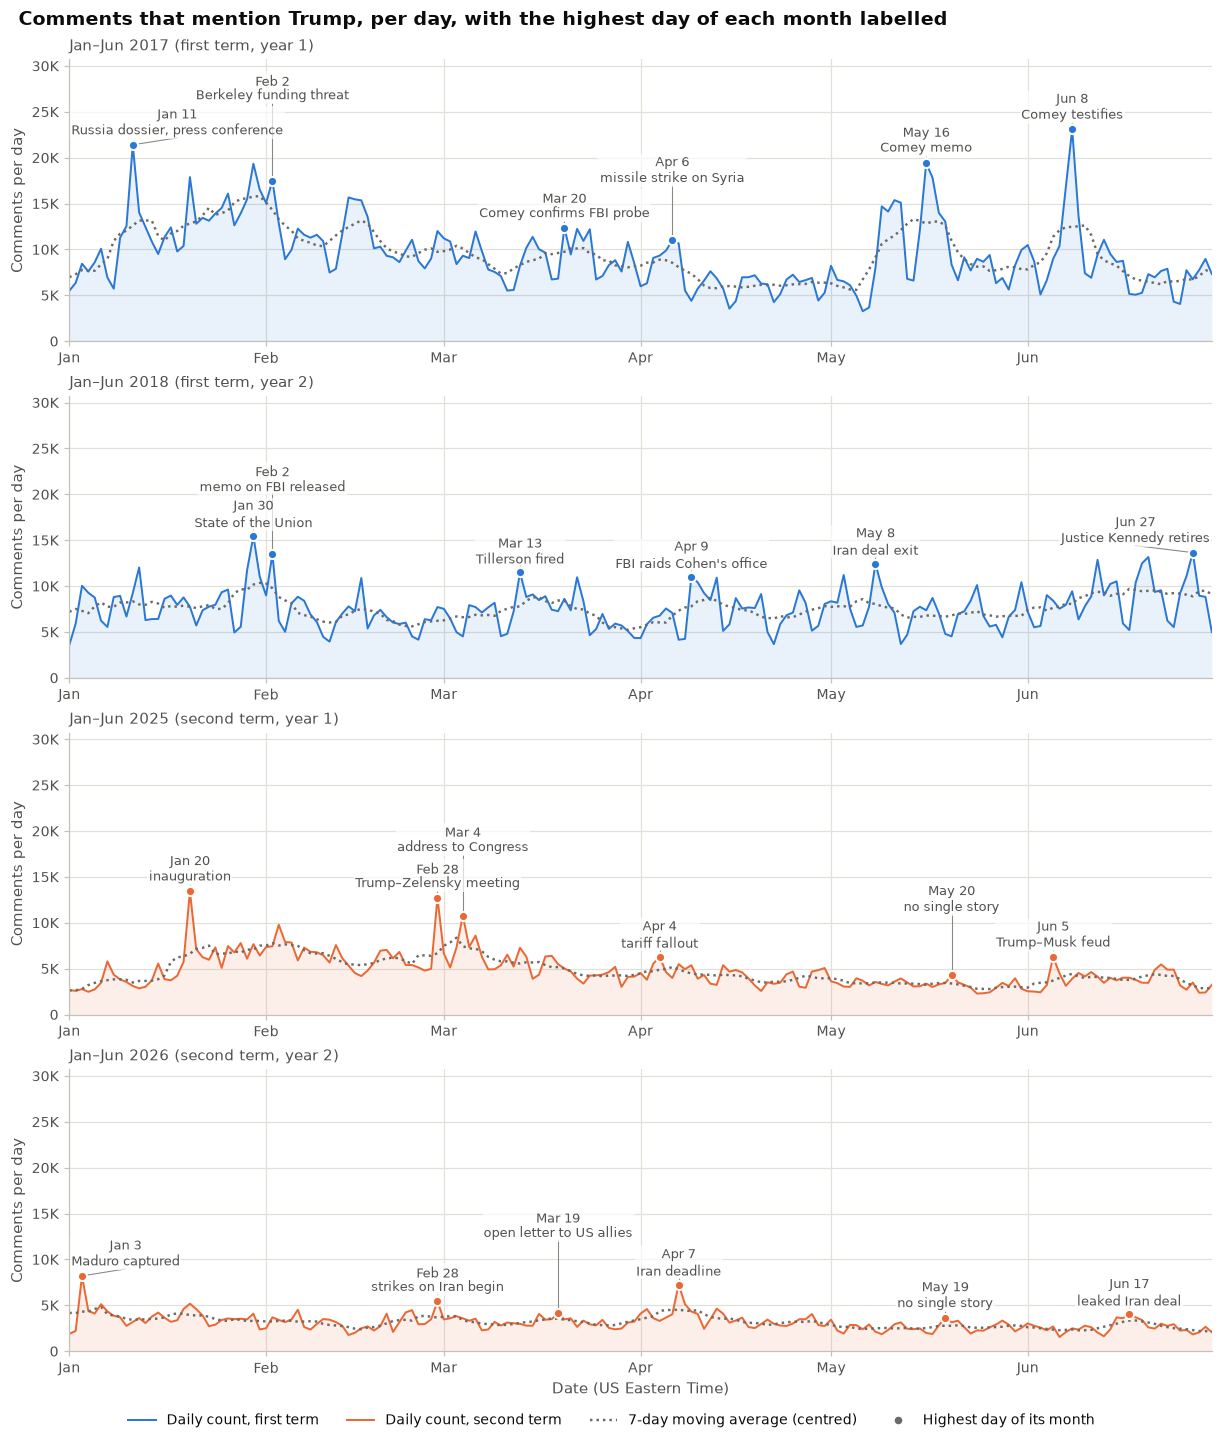

inauguration day 2017-01-20: 17,885 comments, day number 5 of 181 in its window
inauguration day 2025-01-20: 13,413 comments, day number 1 of 181 in its window


,window,month,date,weekday,comments,times the window median,event
0,T1_Y1,Jan,2017-01-11,Wed,21404,2.4,"Russia dossier, press conference"
1,T1_Y1,Feb,2017-02-02,Thu,17483,2.0,Berkeley funding threat
2,T1_Y1,Mar,2017-03-20,Mon,12378,1.4,Comey confirms FBI probe
3,T1_Y1,Apr,2017-04-06,Thu,10979,1.2,missile strike on Syria
4,T1_Y1,May,2017-05-16,Tue,19408,2.2,Comey memo
5,T1_Y1,Jun,2017-06-08,Thu,23103,2.6,Comey testifies
6,T1_Y2,Jan,2018-01-30,Tue,15451,2.1,State of the Union
7,T1_Y2,Feb,2018-02-02,Fri,13519,1.8,memo on FBI released
8,T1_Y2,Mar,2018-03-13,Tue,11485,1.6,Tillerson fired
9,T1_Y2,Apr,2018-04-09,Mon,10996,1.5,FBI raids Cohen's office


In [13]:
TOP_PER_MONTH = 1     # how many days of each month get a label
MIN_GAP_DAYS = 3      # labelled days are at least this many days apart (1 = no restriction)
ROLLING_DAYS = 7    # window of the moving average, in days

# Known events, used to name the labelled days. Dates are US Eastern.
# Each name comes from the largest threads of that day. "no single story" marks a day whose largest threads are about different things.
EVENTS = {
    "2017-01-11": "Russia dossier, press conference",
    "2017-02-02": "Berkeley funding threat",
    "2017-03-20": "Comey confirms FBI probe",
    "2017-04-06": "missile strike on Syria",
    "2017-05-16": "Comey memo",
    "2017-06-08": "Comey testifies",
    "2018-01-30": "State of the Union",
    "2018-02-02": "memo on FBI released",
    "2018-03-13": "Tillerson fired",
    "2018-04-09": "FBI raids Cohen's office",
    "2018-05-08": "Iran deal exit",
    "2018-06-20": "family separations",
    "2018-06-27": "Justice Kennedy retires",
    "2025-01-20": "inauguration",
    "2025-02-03": "DOGE shuts agencies",
    "2025-02-28": "Trump–Zelensky meeting",
    "2025-03-04": "address to Congress",
    "2025-04-04": "tariff fallout",
    "2025-05-20": "no single story",
    "2025-06-05": "Trump–Musk feud",
    "2026-01-03": "Maduro captured",
    "2026-02-28": "strikes on Iran begin",
    "2026-03-19": "open letter to US allies",
    "2026-04-07": "Iran deadline",
    "2026-05-19": "no single story",
    "2026-06-17": "leaked Iran deal",
}


def top_days_per_month(series, n=TOP_PER_MONTH, min_gap_days=MIN_GAP_DAYS):
    """The n highest days of each calendar month, at least min_gap_days apart (also across month borders)."""
    picked = []
    for _, month in series.groupby(series.index.month):
        in_month = []
        for day in month.sort_values(ascending=False).index:
            if all(abs((day - other).days) >= min_gap_days for other in picked + in_month):
                in_month.append(day)
            if len(in_month) == n:
                break
        picked += in_month
    return sorted(picked)


def place_labels(ax, series, days, color):
    """Label each day above the line, lift the label until it is clear of the others, and link it to its day.

    Returns the highest point a label reaches (in comments per day) and the artists that were added.
    """
    renderer = ax.figure.canvas.get_renderer()
    to_px, to_data = ax.transData, ax.transData.inverted()
    frame = ax.get_window_extent(renderer)
    line_px = to_px.transform(np.column_stack([mdates.date2num(series.index), series.to_numpy()]))
    boxes, artists, highest = [], [], 0
    for day in sorted(days, key=lambda d: -series[d]):               # the highest days get the closest spots
        name = EVENTS.get(f"{day:%Y-%m-%d}", "")
        text = ax.text(0, 0, f"{day:%b} {day.day}" + (f"\n{name}" if name else ""), ha="center", va="bottom",
                       fontsize=8.5, color=INK_2, linespacing=1.15, zorder=4,
                       bbox={"facecolor": "white", "edgecolor": "none", "pad": 1, "alpha": 0.7})    # keeps the text readable where a leader line passes behind
        text.set_in_layout(False)
        size = text.get_window_extent(renderer)
        w, h = size.width, size.height
        day_num = mdates.date2num(day)
        x_day, y_day = to_px.transform((day_num, series[day]))
        x = min(max(x_day, frame.x0 + w / 2 + 2), frame.x1 - w / 2 - 2)          # keep the label inside the panel
        below = (line_px[:, 0] >= x - w / 2 - 3) & (line_px[:, 0] <= x + w / 2 + 3)
        y = max(line_px[below, 1].max(), y_day) + 7                               # just above the line under the label
        while any(x - w / 2 < x1 + 4 and x + w / 2 > x0 - 4 and y < y1 + 5 and y + h > y0 - 5 for x0, y0, x1, y1 in boxes):
            y += 3
        boxes.append((x - w / 2, y, x + w / 2, y + h))
        x_text, y_text = to_data.transform((x, y))
        text.set_position((x_text, y_text))
        artists.append(text)
        artists += ax.plot([day_num, x_text], [series[day], y_text], color=MUTED, linewidth=0.7, zorder=2,
                           scalex=False, scaley=False)
        artists += ax.plot([day_num], [series[day]], marker="o", markersize=6, color=color, markeredgecolor="white",
                           markeredgewidth=1.3, zorder=3, scalex=False, scaley=False)
        highest = max(highest, to_data.transform((x, y + h))[1])
    return highest, artists


daily = com.groupby(["period", "date_et"]).size()
peak_rows = []
window_days = {}

fig, axes = plt.subplots(4, 1, figsize=(11, 13), sharey=True, layout="constrained")
for ax, p in zip(axes, PERIODS):
    year = PERIOD_YEAR[p]
    s = daily[p].reindex(pd.date_range(f"{year}-01-01", f"{year}-06-30"), fill_value=0)
    window_days[p] = s
    smooth = s.rolling(ROLLING_DAYS, center=True, min_periods=1).mean()
    ax.fill_between(s.index, s.to_numpy(), color=PERIOD_COLOR[p], alpha=0.10, linewidth=0)
    ax.plot(s.index, s.to_numpy(), color=PERIOD_COLOR[p], linewidth=1.3)
    ax.plot(smooth.index, smooth.to_numpy(), color=NEUTRAL, linewidth=1.6, linestyle=":")
    for day in top_days_per_month(s):
        key = f"{day:%Y-%m-%d}"
        peak_rows.append({"window": p, "month": f"{day:%b}", "date": key, "weekday": f"{day:%a}", "comments": int(s[day]),
                          "times the window median": round(s[day] / s.median(), 1), "event": EVENTS.get(key, "")})
    ax.set_title(PERIOD_LONG[p])
    ax.set_ylabel("Comments per day")
    ax.set_xlim(s.index[0], s.index[-1])
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.yaxis.set_major_formatter(COMPACT)
axes[-1].set_xlabel("Date (US Eastern Time)")
fig.legend(handles=[
    Line2D([], [], color=TERM_COLOR["T1"], linewidth=1.3, label="Daily count, first term"),
    Line2D([], [], color=TERM_COLOR["T2"], linewidth=1.3, label="Daily count, second term"),
    Line2D([], [], color=NEUTRAL, linewidth=1.6, linestyle=":", label=f"{ROLLING_DAYS}-day moving average (centred)"),
    Line2D([], [], color=NEUTRAL, marker="o", linestyle="", markersize=6, markeredgecolor="white",
           label=f"One of the {TOP_PER_MONTH} highest days of its month" if TOP_PER_MONTH > 1 else "Highest day of its month"),
], loc="outside lower center", ncols=4)
headline(fig, "Comments that mention Trump, per day, with the "
              + (f"{TOP_PER_MONTH} highest days" if TOP_PER_MONTH > 1 else "highest day") + " of each month labelled")

# The labels need room above the lines. The shared y-axis is raised until every label fits.
peaks = pd.DataFrame(peak_rows).sort_values("date", ignore_index=True)
y_top = daily.max() * 1.25
for _ in range(8):
    axes[0].set_ylim(0, y_top)
    fig.canvas.draw()                                   # settles the layout, so that text can be measured
    placed = [place_labels(ax, window_days[p], pd.to_datetime(peaks.loc[peaks["window"] == p, "date"]), PERIOD_COLOR[p])
              for ax, p in zip(axes, PERIODS)]
    needed = max(top for top, _ in placed)
    if needed <= y_top:
        break
    for _, artists in placed:
        for artist in artists:
            artist.remove()
    y_top = needed * 1.06
plt.show()

for p, day in {"T1_Y1": pd.Timestamp("2017-01-20"), "T2_Y1": pd.Timestamp("2025-01-20")}.items():
    s = window_days[p]
    print(f"inauguration day {day:%Y-%m-%d}: {s[day]:,} comments, day number {int(s.rank(ascending=False)[day])} of {len(s)} in its window")

peaks

The event names come from the threads, not from the date alone. The table below shows, for each labelled day, the thread with the most comments that mention Trump (the same comment-to-submission link as in section 1.7). On 28 February 2026 the event (strikes on Iran) is in the next-largest threads, not in the largest one.

In [14]:
on_peak_days = com.loc[com["date_et"].isin(pd.to_datetime(peaks["date"])), ["date_et", "submission_id"]]
busiest = (
    on_peak_days.groupby(["date_et", "submission_id"]).size().rename("comments that day").reset_index()
    .sort_values(["date_et", "comments that day"], ascending=[True, False])
    .groupby("date_et").head(1)
    .merge(subs[["id", "subreddit", "title"]], left_on="submission_id", right_on="id", how="left")
)
busiest["date"] = busiest["date_et"].dt.strftime("%Y-%m-%d")
busiest["title"] = busiest["title"].str.slice(0, 115)
busiest[["date", "subreddit", "comments that day", "title"]]

,date,subreddit,comments that day,title
0,2017-01-11,politics,3920,Megathread: Intelligence report claims Russia has compromising information on Trump
1,2017-02-02,politics,2225,Donald Trump threatens to withdraw federal funds from Berkeley University after Breitbart editor talk cancelled
2,2017-03-20,politics,2299,Discussion Megathread: FBI Director Comey Testifies Before House Select Intelligence Committee
3,2017-04-06,politics,714,US military has launched more 50 than missiles aimed at Syria: NBC News
4,2017-05-16,politics,2495,Comey Memo Says Trump Asked Him to End Flynn Investigation
5,2017-06-08,politics,9058,Discussion Megathread: James Comey Testifies before Senate Intelligence Committee
6,2018-01-30,politics,2429,Discussion Thread: 2018 State of the Union Address
7,2018-02-02,politics,2813,Megathread: White House releases controversial memo on allegations of intelligence abuse
8,2018-03-13,politics,1732,"President Trump Fires Secretary of State Rex Tillerson, To Be Replaced By CIA Director Mike Pompeo"
9,2018-04-09,politics,3517,Megathread: F.B.I. Raids Office of Trump’s Longtime Lawyer Michael Cohen


**What we see.**

- Activity is bursty. The highest day of each window is 2.1–3.1 times the median day.
- A label marks the highest day of its month, not an unusual day. In quiet months (April 2017, May 2025, May and June 2026) the labelled day is only 1.0–1.3 times the median.
- Year 1 of each term has a long busy stretch at its start. Year 2 has short, separate peaks.
- The themes of the peaks differ. In the first term half of the labelled days belong to the Russia investigation and the FBI (the dossier, Comey, the FBI memo, the Cohen raid). In the second term half are foreign policy (Zelensky, Maduro, Iran), and in 2026 five of six. The first term has foreign-policy days too (Syria, the Iran deal), so this is a shift, not a clean break.
- The inauguration is the highest day of 2025. In 2017 it is only the fifth-highest day of its window.

**Note on dates.** Days are in US Eastern Time. The windows were cut by UTC month, so 30 June misses its last four hours.

### 1.5 Where: subreddits

**Question:** which communities are the most active, and does the mix change between the terms?

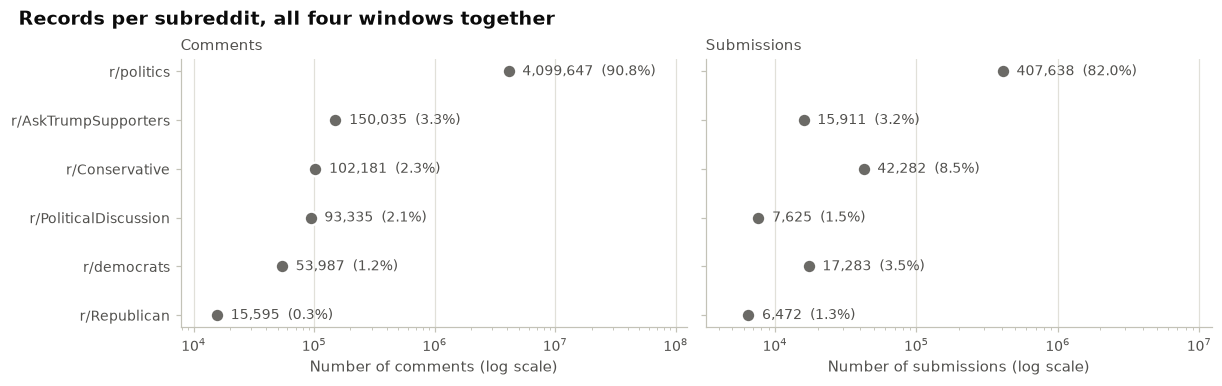

In [15]:
size = pd.DataFrame({
    "comments": com["subreddit"].value_counts(),
    "submissions": subs["subreddit"].value_counts(),
}).reindex(SUBREDDITS)
y_pos = np.arange(len(SUBREDDITS))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True, layout="constrained")
for ax, kind in zip(axes, ["comments", "submissions"]):
    ax.scatter(size[kind], y_pos, s=80, color=NEUTRAL, edgecolor="white", linewidth=1.5, zorder=3)
    for v, yy in zip(size[kind], y_pos):
        ax.annotate(f"{v:,}  ({100 * v / size[kind].sum():.1f}%)", (v, yy), xytext=(9, 0), textcoords="offset points",
                    va="center", fontsize=9, color=INK_2)
    ax.set_xscale("log")
    ax.set_xlim(size[kind].min() / 2, size[kind].max() * 30)
    ax.set_xlabel(f"Number of {kind} (log scale)")
    ax.set_title(kind.capitalize())
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(y_pos, [f"r/{s}" for s in SUBREDDITS])
axes[0].invert_yaxis()
headline(fig, "Records per subreddit, all four windows together")
plt.show()

**What we see.** The scale is logarithmic.

- r/politics holds 90.8% of the comments and 82.0% of the submissions. Its gap to r/Republican is a factor of 260 in comments.
- r/Conservative is second by submissions (8.5%) but third by comments (2.3%): many posts, few comments under each.
- r/AskTrumpSupporters is the opposite: 3.2% of the submissions and 3.3% of the comments, with long discussions under few posts.

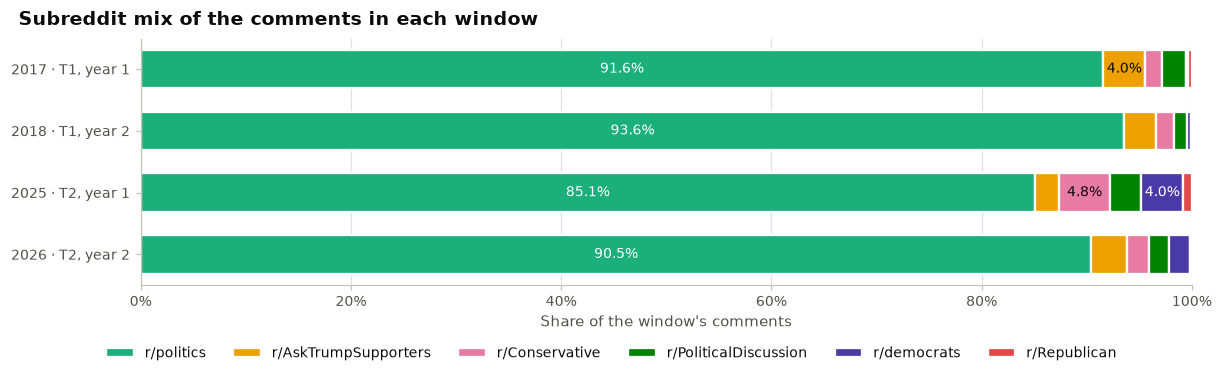

In [16]:
mix = 100 * pd.crosstab(com["period"], com["subreddit"], normalize="index").reindex(index=PERIODS, columns=SUBREDDITS)
rows = [PERIOD_SHORT[p].replace("\n", " · ") for p in PERIODS]

fig, ax = plt.subplots(figsize=(11, 3.3), layout="constrained")
left = np.zeros(len(PERIODS))
for s in SUBREDDITS:
    bars = ax.barh(rows, mix[s].values, left=left, height=0.62, color=SUB_COLOR[s], edgecolor="white", linewidth=1.5, label=f"r/{s}")
    for rect, v in zip(bars, mix[s].values):
        if v >= 3.5:
            ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height() / 2, f"{v:.1f}%",
                    ha="center", va="center", fontsize=9, color=ink_on(SUB_COLOR[s]))
    left += mix[s].values
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PERCENT)
ax.set_xlabel("Share of the window's comments")
ax.grid(axis="y", visible=False)
fig.legend(loc="outside lower center", ncols=6)
headline(fig, "Subreddit mix of the comments in each window")
plt.show()

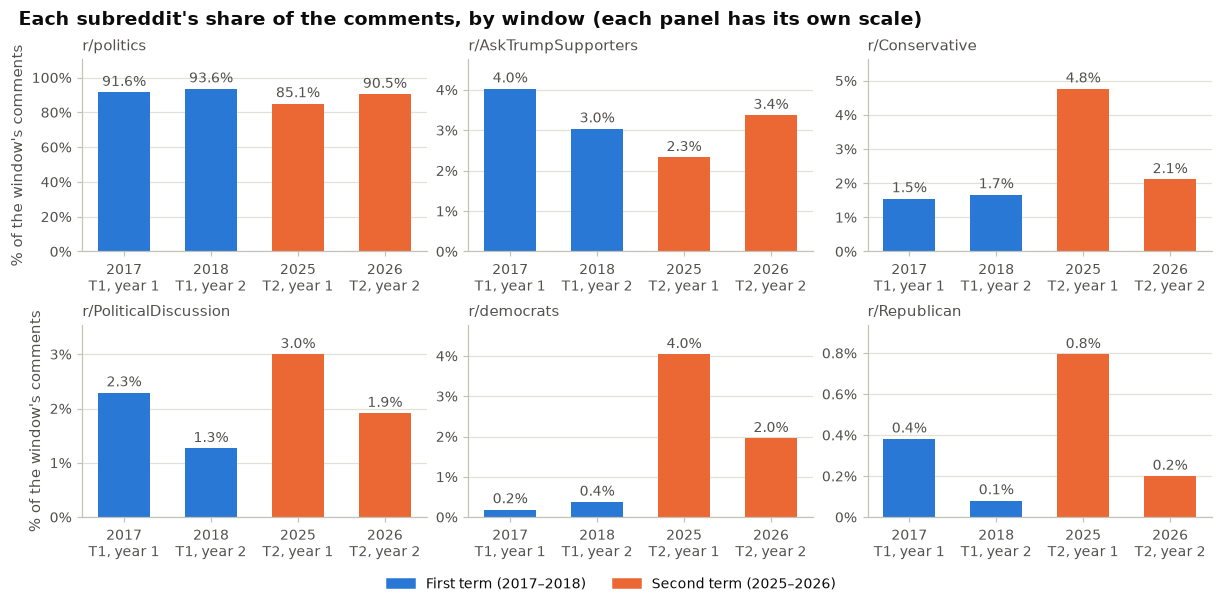

period,T1_Y1,T1_Y2,T2_Y1,T2_Y2,All
subreddit,,,,,
politics,"1,577,716","1,278,934","726,710","516,287","4,099,647"
AskTrumpSupporters,"69,382","41,510","19,896","19,247","150,035"
Conservative,"26,688","22,772","40,687","12,034","102,181"
PoliticalDiscussion,"39,499","17,312","25,598","10,926","93,335"
democrats,"3,231","5,103","34,493","11,160","53,987"
Republican,"6,574","1,101","6,778","1,142","15,595"
All,"1,723,090","1,366,732","854,162","570,796","4,514,780"


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(11, 5.4), layout="constrained")
for ax, s in zip(axes.flat, SUBREDDITS):
    bars = ax.bar([PERIOD_SHORT[p] for p in PERIODS], mix[s].values, width=0.6, color=[PERIOD_COLOR[p] for p in PERIODS])
    ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=9, color=INK_2)
    ax.set_title(f"r/{s}")
    ax.set_ylim(0, mix[s].max() * 1.18)
    ax.yaxis.set_major_formatter(PERCENT)
    ax.grid(axis="x", visible=False)
for ax in axes[:, 0]:
    ax.set_ylabel("% of the window's comments")
fig.legend(handles=term_handles(), loc="outside lower center", ncols=2)
headline(fig, "Each subreddit's share of the comments, by window (each panel has its own scale)")
plt.show()

counts = pd.crosstab(com["subreddit"], com["period"], margins=True, margins_name="All").reindex(SUBREDDITS + ["All"])
with_commas(counts)

**What we see.**

- r/politics stays between 85% and 94% in every window.
- 2025 is the most diverse window. r/politics drops to 85.1%, and r/Conservative (4.8%), r/democrats (4.0%) and r/PoliticalDiscussion (3.0%) reach their highest shares.
- r/democrats changes the most: from 3,231 comments in 2017 to 34,493 in 2025, while the dataset halved.

**What it means for the project.** The community mix changes, so support and opposition must be compared inside each subreddit, not on pooled data.

### 1.6 Who: authors

**Question:** how unequal is the activity of authors, and are the second-term authors the same people as in the first term?

Comments from deleted accounts (`[deleted]`) cannot be attributed to a person and are left out here.

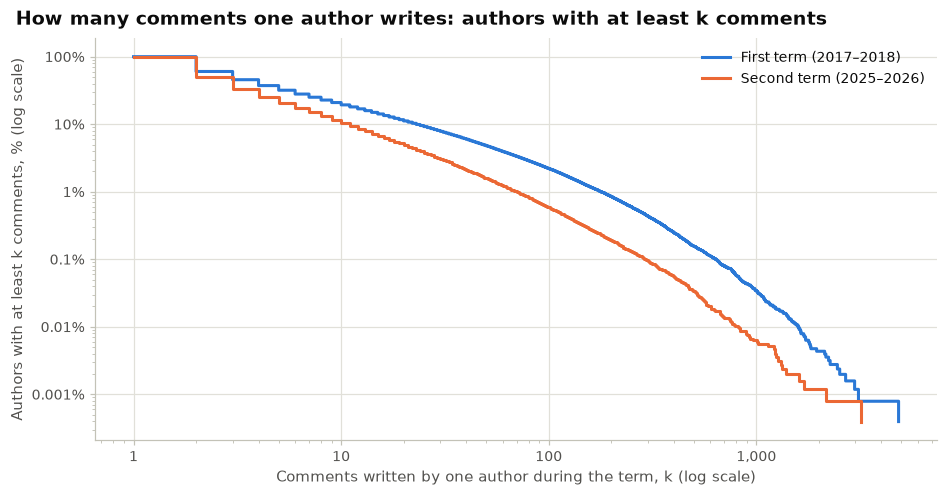

In [18]:
per_author = named.groupby(["term", "author"]).size()

fig, ax = plt.subplots(figsize=(8.5, 4.4), layout="constrained")
for term in TERMS:
    k, n_authors = np.unique(per_author[term].to_numpy(), return_counts=True)
    at_least_k = 100 * n_authors[::-1].cumsum()[::-1] / n_authors.sum()
    ax.plot(k, at_least_k, color=TERM_COLOR[term], drawstyle="steps-post", label=TERM_LABEL[term])
ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.yaxis.set_major_formatter(PERCENT)
ax.set_xlabel("Comments written by one author during the term, k (log scale)")
ax.set_ylabel("Authors with at least k comments, % (log scale)")
ax.legend()
headline(fig, "How many comments one author writes: authors with at least k comments")
plt.show()

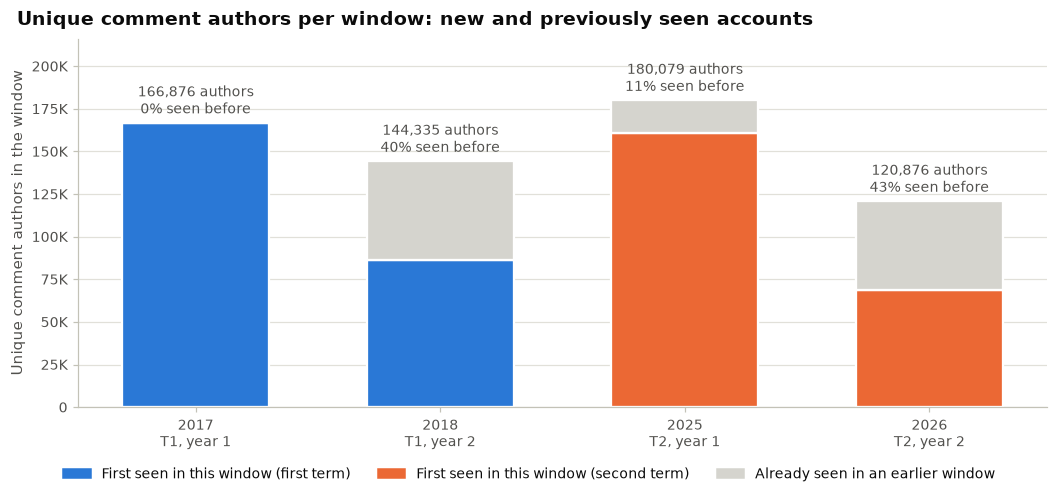

,value
authors active in the first term only,"228,396"
authors active in the second term only,"229,296"
authors active in both terms,"24,776"
share of second-term authors who also wrote in the first term,9.8%
share of second-term comments written by these authors,16.6%


In [19]:
# one row per author and year; the year stands for the window (2017, 2018, 2025, 2026)
author_year = named.groupby(["author", "year"]).size().reset_index(name="comments")
author_year["is_new"] = author_year["year"] == author_year.groupby("author")["year"].transform("min")

new_vs_seen = author_year.groupby("year")["is_new"].agg(new="sum", total="size").loc[list(PERIOD_YEAR.values())]
new_vs_seen["seen"] = new_vs_seen["total"] - new_vs_seen["new"]
labels = [PERIOD_SHORT[p] for p in PERIODS]

fig, ax = plt.subplots(figsize=(9.5, 4.4), layout="constrained")
ax.bar(labels, new_vs_seen["new"], width=0.6, color=[PERIOD_COLOR[p] for p in PERIODS], edgecolor="white", linewidth=1.5)
bars = ax.bar(labels, new_vs_seen["seen"], bottom=new_vs_seen["new"], width=0.6, color="#d5d4ce", edgecolor="white", linewidth=1.5)
ax.bar_label(bars, labels=[f"{t:,} authors\n{100 * s / t:.0f}% seen before" for s, t in zip(new_vs_seen["seen"], new_vs_seen["total"])],
             padding=3, fontsize=9, color=INK_2)
ax.set_ylim(0, new_vs_seen["total"].max() * 1.2)
ax.yaxis.set_major_formatter(COMPACT)
ax.set_ylabel("Unique comment authors in the window")
ax.grid(axis="x", visible=False)
fig.legend(handles=[Patch(color=TERM_COLOR["T1"], label="First seen in this window (first term)"),
                    Patch(color=TERM_COLOR["T2"], label="First seen in this window (second term)"),
                    Patch(color="#d5d4ce", label="Already seen in an earlier window")], loc="outside lower center", ncols=3)
headline(fig, "Unique comment authors per window: new and previously seen accounts")
plt.show()

terms_per_author = per_author.unstack("term").fillna(0)
both = (terms_per_author["T1"] > 0) & (terms_per_author["T2"] > 0)
pd.Series({
    "authors active in the first term only": f"{((terms_per_author['T1'] > 0) & ~both).sum():,}",
    "authors active in the second term only": f"{((terms_per_author['T2'] > 0) & ~both).sum():,}",
    "authors active in both terms": f"{both.sum():,}",
    "share of second-term authors who also wrote in the first term": f"{100 * both.sum() / (terms_per_author['T2'] > 0).sum():.1f}%",
    "share of second-term comments written by these authors": f"{100 * terms_per_author.loc[both, 'T2'].sum() / terms_per_author['T2'].sum():.1f}%",
}, name="value").to_frame()

**What we see.**

- Activity is very unequal: 40% of the first-term authors and 50% of the second-term authors wrote a single comment.
- Inside a term the audience carries over: 40% of the 2018 authors and 43% of the 2026 authors had written in an earlier window. Across the seven-year gap it does not: only 11% of the 2025 authors appear in the first-term data.
- 24,776 accounts are active in both terms. They are 9.8% of the second-term authors and wrote 16.6% of the second-term comments.

**What it means for the project.** The two terms are mostly two different groups of people. The returning authors are a natural panel for the question "did the same people change their tone?".

### 1.7 Thread structure

**Question:** how much of a thread is about Trump, and are comments direct reactions to the post or replies to each other?

This is the only place where the two tables are merged. Comments are counted per thread and joined to the submissions on `comments.submission_id = submissions.id`, one row per submission. This puts two numbers side by side: `num_comments`, the size of the whole thread as Reddit reports it, and `trump_comments`, the comments in it that mention Trump.

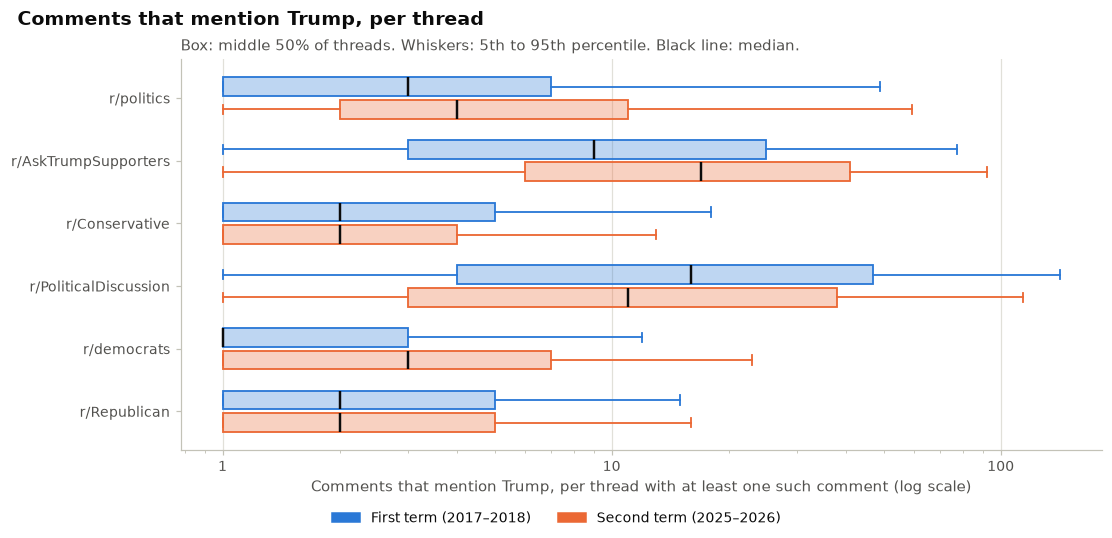

term,"median per thread, first term (2017–2018)","median per thread, second term (2025–2026)"
subreddit,,
r/politics,3,4
r/AskTrumpSupporters,9,17
r/Conservative,2,2
r/PoliticalDiscussion,16,11
r/democrats,1,3
r/Republican,2,2


,value
threads in the submissions table,"497,211"
threads with no comment that mentions Trump,34.9%
threads with exactly 1 such comment,18.6%
median such comments per thread (threads with at least 1),3
comments held by the 1% largest threads,32.6%


In [20]:
threads = subs.merge(comment_counts.rename("trump_comments"), left_on="id", right_index=True, how="left")
threads["trump_comments"] = threads["trump_comments"].fillna(0).astype("int32")
assert len(threads) == len(subs)


def term_boxes(ax, df, column, terms=TERMS):
    """One horizontal box per subreddit and term. Box = middle 50%, whiskers = 5th to 95th percentile, line = median."""
    groups = df.groupby(["subreddit", "term"])[column]
    for i, s in enumerate(SUBREDDITS):
        for j, term in enumerate(terms):
            if (s, term) not in groups.groups:
                continue
            position = i + (j - (len(terms) - 1) / 2) * 0.36
            color = TERM_COLOR[term]
            ax.boxplot(groups.get_group((s, term)).dropna().to_numpy(), positions=[position], orientation="horizontal",
                       whis=(5, 95), showfliers=False, patch_artist=True, widths=0.3, manage_ticks=False,
                       boxprops={"facecolor": mcolors.to_rgba(color, 0.30), "edgecolor": color, "linewidth": 1.2},
                       medianprops={"color": INK, "linewidth": 1.6},
                       whiskerprops={"color": color, "linewidth": 1.2}, capprops={"color": color, "linewidth": 1.2})
    ax.set_yticks(range(len(SUBREDDITS)), [f"r/{s}" for s in SUBREDDITS])
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)


with_comments = threads.loc[threads["trump_comments"] > 0]

fig, ax = plt.subplots(figsize=(10, 4.8), layout="constrained")
term_boxes(ax, with_comments, "trump_comments")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_xlabel("Comments that mention Trump, per thread with at least one such comment (log scale)")
ax.set_title("Box: middle 50% of threads. Whiskers: 5th to 95th percentile. Black line: median.")
fig.legend(handles=term_handles(), loc="outside lower center", ncols=2)
headline(fig, "Comments that mention Trump, per thread")
plt.show()

display(with_comments.groupby(["subreddit", "term"])["trump_comments"].median().unstack("term").reindex(SUBREDDITS).astype(int)
        .rename(columns={t: f"median per thread, {TERM_LABEL[t].lower()}" for t in TERMS}).rename(index=lambda s: f"r/{s}"))

pd.Series({
    "threads in the submissions table": f"{len(threads):,}",
    "threads with no comment that mentions Trump": f"{100 * (threads['trump_comments'] == 0).mean():.1f}%",
    "threads with exactly 1 such comment": f"{100 * (threads['trump_comments'] == 1).mean():.1f}%",
    "median such comments per thread (threads with at least 1)": f"{with_comments['trump_comments'].median():.0f}",
    "comments held by the 1% largest threads": f"{100 * with_comments['trump_comments'].nlargest(len(with_comments) // 100).sum() / with_comments['trump_comments'].sum():.1f}%",
}, name="value").to_frame()

**What we see.**

- 34.9% of the threads have no comment that mentions Trump (the post itself does), and another 18.6% have exactly one.
- Megathreads dominate. The median thread with such comments has 3 of them, while the 1% largest threads hold 32.6% of all comments.
- The two discussion subreddits have much deeper threads: a median of 9–17 in r/AskTrumpSupporters and 11–16 in r/PoliticalDiscussion, against 1–4 elsewhere.

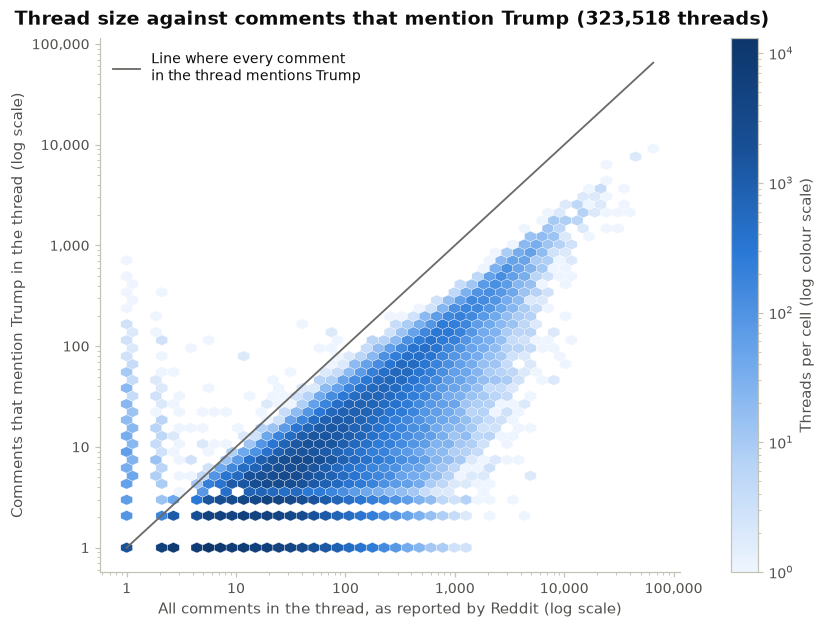

Spearman rank correlation: 0.76
Comments that mention Trump as a share of all comments in these threads: 13.3%
Threads with more Trump comments than Reddit's num_comments: 0.22%


In [21]:
both_positive = with_comments.loc[with_comments["num_comments"] > 0]
rank_correlation = both_positive["num_comments"].rank().corr(both_positive["trump_comments"].rank())

fig, ax = plt.subplots(figsize=(7.4, 5.6), layout="constrained")
hb = ax.hexbin(both_positive["num_comments"], both_positive["trump_comments"], xscale="log", yscale="log",
               gridsize=45, bins="log", mincnt=1, cmap=BLUES, linewidths=0.2, edgecolors="white")
limit = both_positive[["num_comments", "trump_comments"]].max().max()
ax.plot([1, limit], [1, limit], color=NEUTRAL, linewidth=1.2, label="Line where every comment\nin the thread mentions Trump")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlabel("All comments in the thread, as reported by Reddit (log scale)")
ax.set_ylabel("Comments that mention Trump in the thread (log scale)")
ax.grid(False)
fig.colorbar(hb, ax=ax, label="Threads per cell (log colour scale)")
headline(fig, f"Thread size against comments that mention Trump ({len(both_positive):,} threads)")
plt.show()

density = both_positive["trump_comments"].sum() / both_positive["num_comments"].sum()
print(f"Spearman rank correlation: {rank_correlation:.2f}")
print(f"Comments that mention Trump as a share of all comments in these threads: {100 * density:.1f}%")
print(f"Threads with more Trump comments than Reddit's num_comments: {100 * (both_positive['trump_comments'] > both_positive['num_comments']).mean():.2f}%")

**What we see.**

- Larger threads contain more comments that mention Trump (rank correlation 0.76).
- The cloud lies well below the diagonal: only 13.3% of the comments in these threads mention Trump by name.
- 0.22% of the threads lie above the diagonal, which is impossible. `num_comments` is most likely a snapshot taken before the thread finished growing.

**What it means for the project.** The keyword filter keeps about one comment in eight from a Trump-related thread. Our comments are the explicit mentions, not the whole conversation.

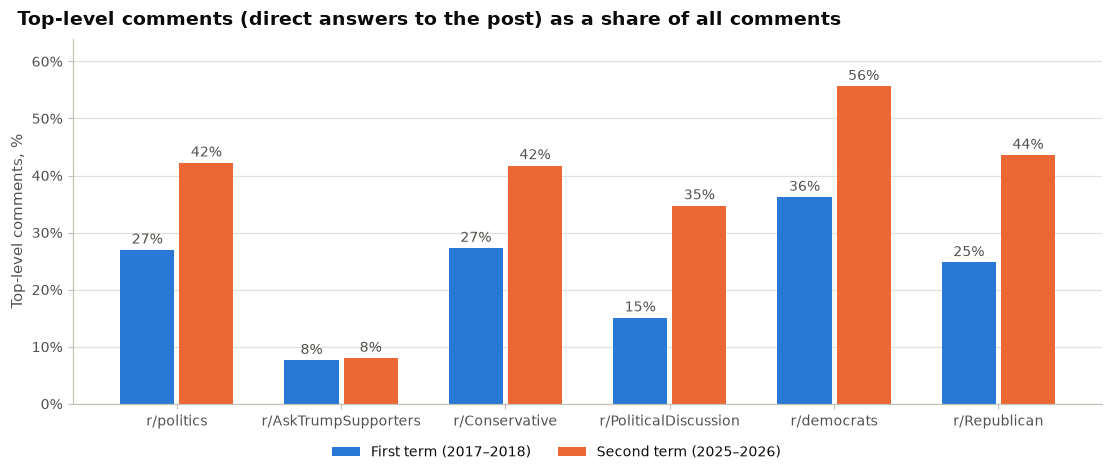

In [22]:
top_level = 100 * com.groupby(["subreddit", "term"])["is_top_level"].mean().unstack("term").reindex(SUBREDDITS)
x_pos = np.arange(len(SUBREDDITS))

fig, ax = plt.subplots(figsize=(10, 4.2), layout="constrained")
for j, term in enumerate(TERMS):
    bars = ax.bar(x_pos + (j - 0.5) * 0.36, top_level[term], width=0.33, color=TERM_COLOR[term], label=TERM_LABEL[term])
    ax.bar_label(bars, fmt="%.0f%%", padding=2, fontsize=9, color=INK_2)
ax.set_xticks(x_pos, [f"r/{s}" for s in SUBREDDITS])
ax.set_ylim(0, top_level.max().max() * 1.15)
ax.yaxis.set_major_formatter(PERCENT)
ax.set_ylabel("Top-level comments, %")
ax.grid(axis="x", visible=False)
fig.legend(loc="outside lower center", ncols=2)
headline(fig, "Top-level comments (direct answers to the post) as a share of all comments")
plt.show()

**What we see.**

- Outside r/AskTrumpSupporters the share of top-level comments rises by 15–20 points in every subreddit: from 15–36% in the first term to 35–56% in the second.
- r/AskTrumpSupporters stays at 8%. Its format, a question followed by long reply chains, did not change.

Second-term comments are more often separate reactions to the post than replies between users, which fits the finding that second-term authors write fewer comments each.

### 1.8 Reception: controversy

**Question:** how contested are comments that mention Trump, and does it differ between windows and communities?

`controversiality` is Reddit's own flag for comments with many votes in both directions.

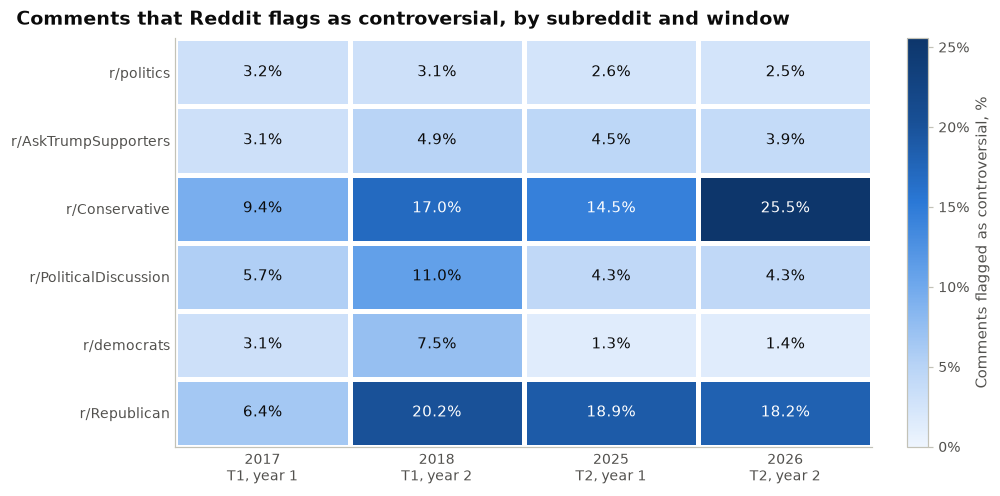

In [23]:
controversial = 100 * com.groupby(["subreddit", "period"])["controversiality"].mean().unstack("period").reindex(index=SUBREDDITS, columns=PERIODS)

fig, ax = plt.subplots(figsize=(9, 4.4), layout="constrained")
mesh = ax.pcolormesh(controversial.to_numpy(), cmap=BLUES, vmin=0, edgecolors="white", linewidth=2)
for i in range(controversial.shape[0]):
    for j in range(controversial.shape[1]):
        v = controversial.iat[i, j]
        ax.text(j + 0.5, i + 0.5, f"{v:.1f}%", ha="center", va="center", fontsize=9.5, color=ink_on(mesh.cmap(mesh.norm(v))))
ax.set_xticks(np.arange(len(PERIODS)) + 0.5, [PERIOD_SHORT[p] for p in PERIODS])
ax.set_yticks(np.arange(len(SUBREDDITS)) + 0.5, [f"r/{s}" for s in SUBREDDITS])
ax.invert_yaxis()
ax.grid(False)
ax.tick_params(length=0)
fig.colorbar(mesh, ax=ax, label="Comments flagged as controversial, %", format=PERCENT)
headline(fig, "Comments that Reddit flags as controversial, by subreddit and window")
plt.show()

**What we see.**

- Controversy is concentrated in the right-leaning communities. In r/Conservative 9.4% of comments were controversial in 2017 and 25.5% in 2026. In r/Republican the share is 18–20% from 2018 onward.
- r/politics is low and stable (2.5–3.2%), and r/democrats is the least contested in the second term (1.3–1.4%).
- 2018 is more contested than 2017 in every subreddit except r/politics.

**What it means for the project.** In r/Conservative one comment in four that mentions Trump now splits the voters. Whether this is a split among conservatives is hypothesis 4 in section 1.10.

### 1.9 Declared stance in r/AskTrumpSupporters

**Question:** in the one community where every author declares a side, does the balance between supporters and nonsupporters move between the terms?

The declared stance is counted per comment (how much each side says) and per unique author (how many people are on each side). An author who changed flair inside a window is counted once for each flair.

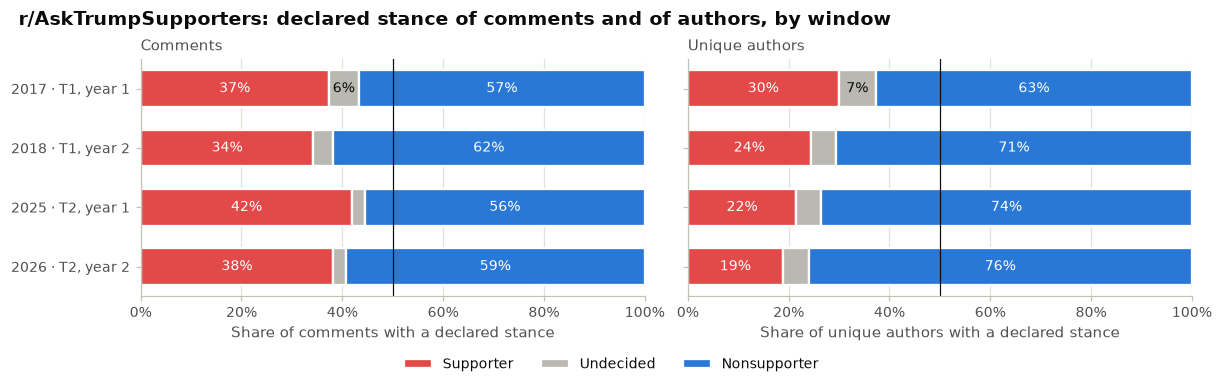

comments                                      unique authors                                     
stance            nonsupporter other / no flair supporter undecided   nonsupporter other / no flair supporter undecided
2017 · T1, year 1       35,888            6,072    23,591     3,831          3,201            1,333     1,528       379
2018 · T1, year 2       25,356              536    14,036     1,582          2,097               14       724       150
2025 · T2, year 1       11,019               45     8,332       500          1,939               44       567       130
2026 · T2, year 2       11,375               66     7,323       483          1,446               53       358        98

In [24]:
ats = com.loc[com["subreddit"] == "AskTrumpSupporters", ["period", "author", "author_deleted", "stance"]].copy()
ats["stance"] = ats["stance"].where(ats["stance"].isin(STANCES), "other / no flair")

stance_comments = pd.crosstab(ats["period"], ats["stance"]).reindex(PERIODS)
ats_authors = ats.loc[~ats["author_deleted"], ["period", "author", "stance"]].drop_duplicates()
stance_authors = pd.crosstab(ats_authors["period"], ats_authors["stance"]).reindex(PERIODS)
rows = [PERIOD_SHORT[p].replace("\n", " · ") for p in PERIODS]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True, layout="constrained")
for ax, (label, table) in zip(axes, {"Comments": stance_comments, "Unique authors": stance_authors}.items()):
    share = 100 * table[STANCES].div(table[STANCES].sum(axis=1), axis=0)
    left = np.zeros(len(PERIODS))
    for stance in STANCES:
        bars = ax.barh(rows, share[stance].values, left=left, height=0.62, color=STANCE_COLOR[stance],
                       edgecolor="white", linewidth=1.5, label=stance.capitalize())
        for rect, v in zip(bars, share[stance].values):
            if v >= 6:
                ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height() / 2, f"{v:.0f}%",
                        ha="center", va="center", fontsize=9, color=ink_on(STANCE_COLOR[stance]))
        left += share[stance].values
    ax.axvline(50, color=INK, linewidth=0.8)
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(PERCENT)
    ax.set_xlabel(f"Share of {label.lower()} with a declared stance")
    ax.set_title(label)
    ax.grid(axis="y", visible=False)
axes[0].invert_yaxis()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3)
headline(fig, "r/AskTrumpSupporters: declared stance of comments and of authors, by window")
plt.show()

stance_table = pd.concat({"comments": stance_comments, "unique authors": stance_authors}, axis=1)
stance_table.index = [PERIOD_SHORT[p].replace("\n", " · ") for p in PERIODS]
with_commas(stance_table)

In [25]:
per_stance = (stance_comments[STANCES] / stance_authors[STANCES]).round(1)
per_stance.index = [PERIOD_SHORT[p].replace("\n", " · ") for p in PERIODS]
per_stance.columns = [f"comments per {s} author" for s in STANCES]
per_stance

,comments per supporter author,comments per undecided author,comments per nonsupporter author
"2017 · T1, year 1",15.4,10.1,11.2
"2018 · T1, year 2",19.4,10.5,12.1
"2025 · T2, year 1",14.7,3.8,5.7
"2026 · T2, year 2",20.5,4.9,7.9


**What we see.**

- Nonsupporters are the majority in both counts and in every window.
- By comments the balance is stable: supporters write 34–42% and nonsupporters 56–62%.
- By people it is not: supporters fall from 30% of the authors in 2017 to 19% in 2026, from 1,528 accounts to 358.
- Supporters write much more: 15–21 comments each per window, against 11–12 for a nonsupporter in the first term and 6–8 in the second.

**What it means for the project.** A shrinking group of supporters keeps its share of comments by writing more, so the share of supportive comments and the share of supportive people are different measures, and we report both. In this subreddit supporters answer and nonsupporters ask, so its balance cannot be generalised to Reddit.

### 1.10 Summary and next steps

**What the data shows so far**

1. **Clean, but filtered.** 4.5M comments and 0.5M submissions, no duplicates, no gaps in the core fields. Every record mentions "Trump", so the counts describe this dataset, not Trump's share of Reddit.
2. **Less text, the same number of people.** Comments fall from 3.1M in the first term to 1.4M in the second, with about 253K authors in each. Second-term authors write half as much (4.7 against 10 comments per window) and reply to each other less.
3. **The same rhythm in both terms.** Year 1 starts high and decays, year 2 is flat. Peaks follow the news: the Russia investigation in 2017–2018, foreign policy in 2025–2026.
4. **One community dominates.** r/politics is 85–94% of every window. The rest of the mix changes: r/democrats has ten times more comments in 2025 than in 2017.
5. **Two different audiences.** Only 10% of second-term authors wrote in the first term. These 24,776 accounts are a natural panel.
6. **Right-leaning subreddits are contested.** In r/Conservative controversial comments rise from 9% in 2017 to 26% in 2026. In r/politics they stay near 3%.
7. **Declared supporters: fewer people, the same voice.** In r/AskTrumpSupporters supporters fall from 30% to 19% of the authors but keep 34–42% of the comments.

**Limits**

- The two terms come from different archives: records were saved 3–5 weeks after posting in the first term and 1.5 days after in the second. Scores, edits and deletions are not comparable across terms.
- The keyword filter keeps about one comment in eight from a Trump-related thread.
- Pooled numbers describe r/politics, so every comparison is made inside a subreddit.

**Predicted stance: ready for the next stage**

Every comment now has a **predicted stance** toward Trump: `against`, `neutral` or `pro`, with class probabilities. The labels come from a DistilRoBERTa classifier trained on the answers of an instructed local LLM (`model_selection.ipynb`, `scripts/infer_stance.py`). Comments that mention Trump only in a quote (5.5%) have no label.

The classifier is noisy: macro-F1 is 0.69 against the LLM and 0.54 against 149 manual labels, and about half of its labels are `neutral`. It still separates the sides: in r/AskTrumpSupporters it marks 31% of supporters' comments as `pro` and 6.5% of nonsupporters'. So we compare shares between groups and do not trust single labels.

**Hypotheses to test**

The measure is the share of `pro` and `against` among the labelled comments, inside one subreddit.

1. **Honeymoon.** In both terms the `pro` share is lower in year 2 than in year 1.
2. **A harder second term.** Inside the same subreddit, 2025–2026 has fewer `neutral` and more `against` comments than 2017–2018.
3. **Events move volume, not balance.** On peak days the stance shares stay close to the window average.
4. **Controversy in r/Conservative is a split among conservatives.** Controversial comments there are `against` more often than the other comments, and the gap grows by 2026.
5. **New people, not changed minds.** The 24,776 returning authors changed their stance less than the pooled numbers suggest.
6. **Communities reward their own side.** `pro` comments score higher in r/Conservative and r/Republican, `against` comments in r/politics and r/democrats. Compared inside one term only, because of the archive difference.
7. **Supporters turn critical.** Declared supporters in r/AskTrumpSupporters have a lower `pro` share in 2026 than in 2017.
8. **Format matters.** Top-level comments take a side more often than replies, so the rise of top-level comments in the second term can shift the pooled stance by itself.

**Next steps**

1. Check the classifier's bias by subreddit and window before reading any trend.
2. Stance over time: shares per month and on peak days, per subreddit.
3. Authors: the returning panel, and how concentrated each stance is.
4. Text: words and topics that separate `pro` from `against` in each term.